# 노인 trip 추가 분석 — OD · 시간대 · 노선

**3가지 분석을 한 노트북에 묶음** (사고/횡단보도 제외):

1. **OD 흐름 분석** — 어느 구 → 어느 구, 자족형 vs 출타형
2. **시간대별 활동** — 시간대별 승차, 이동거리, 환승 부담 변화
3. **노선·운영사별 점유율** — 노인 의존 노선 식별

**데이터**: `elderly_card_trips` (505K), `monthly_transfer_accessibility`, `route_station`, `railway_line`

In [36]:
# ============================================================
# 셀 1 - 환경 + DB 헬퍼
# ============================================================
import duckdb
import pandas as pd
import json
import logging
import matplotlib.pyplot as plt
from pathlib import Path
from contextlib import contextmanager

DB_PATH = "data/seoul.duckdb"

@contextmanager
def db_open(read_only: bool = False):
    con = duckdb.connect(DB_PATH, read_only=read_only)
    try: yield con
    finally: con.close()

# matplotlib 한글 폰트 (macOS=AppleGothic만 사용 + 폰트 워닝 끔)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

print(f"DB: {DB_PATH}")

DB: data/seoul.duckdb


---

## 1. OD 흐름 분석

노인이 어디서 어디로 이동하는가?

In [37]:
# ============================================================
# 셀 2 - 구 단위 OD 매트릭스 (서울 출발)
# ============================================================
with db_open(read_only=True) as con:
    od = con.execute("""
        WITH ride_sgg AS (
            SELECT ect.vr_card_no, ect.ride_dt, ect.rte_id,
                   rs.sgg_cd AS ride_sgg, rs.ctpv_cd AS ride_ctpv,
                   ect.goff_sttn_id
            FROM elderly_card_trips ect
            LEFT JOIN route_station rs ON rs.sttn_id = ect.ride_sttn_id
            WHERE rs.ctpv_cd = '11'
        ),
        od_pairs AS (
            SELECT r.ride_sgg, gs.sgg_cd AS goff_sgg, gs.ctpv_cd AS goff_ctpv,
                   COUNT(*) AS trip_cnt
            FROM ride_sgg r
            LEFT JOIN route_station gs ON gs.sttn_id = r.goff_sttn_id
            WHERE r.ride_sgg IS NOT NULL AND gs.sgg_cd IS NOT NULL
            GROUP BY r.ride_sgg, gs.sgg_cd, gs.ctpv_cd
        ),
        sgg_names AS (
            SELECT sido_cd || sgg_cd AS code,
                   regexp_replace(locatadd_nm, '^(서울특별시|인천광역시|경기도) ', '') AS nm
            FROM region
            WHERE sgg_cd<>'000' AND umd_cd='000' AND ri_cd='00'
        )
        SELECT od.ride_sgg, rn.nm AS ride_nm,
               od.goff_sgg, gn.nm AS goff_nm,
               od.goff_ctpv, od.trip_cnt
        FROM od_pairs od
        LEFT JOIN sgg_names rn ON rn.code = od.ride_sgg
        LEFT JOIN sgg_names gn ON gn.code = od.goff_sgg
        ORDER BY od.trip_cnt DESC
    """).df()

print(f"OD 페어 (서울 출발): {len(od):,}개")
print(f"총 trip: {od['trip_cnt'].sum():,}건\n")
print("=== TOP 20 OD 페어 ===")
print(od.head(20)[['ride_nm','goff_nm','goff_ctpv','trip_cnt']].to_string())

OD 페어 (서울 출발): 719개
총 trip: 2,744,671건

=== TOP 20 OD 페어 ===
   ride_nm goff_nm goff_ctpv  trip_cnt
0      강남구     강남구        11    142383
1      강북구     강북구        11     91174
2     동대문구    동대문구        11     86796
3      송파구    남양주시        41     69351
4      성북구     성북구        11     69272
5      종로구     종로구        11     68499
6      관악구     관악구        11     68334
7       중구      중구        11     65971
8      송파구     송파구        11     64122
9      송파구     포천시        41     46980
10     은평구     은평구        11     46123
11     서초구     서초구        11     45523
12     중랑구     중랑구        11     44311
13     구로구     구로구        11     41410
14    서대문구    서대문구        11     40509
15      중구     종로구        11     40495
16    영등포구    영등포구        11     40242
17     동작구     동작구        11     38630
18     양천구     양천구        11     38538
19     강서구     강서구        11     36999


In [38]:
# ============================================================
# 셀 3 - 자족형 구 vs 출타형 구
# ============================================================
stats = od.copy()
stats['is_self'] = stats['ride_sgg'] == stats['goff_sgg']
stats['is_seoul'] = stats['goff_ctpv'] == '11'

ride_total = stats.groupby('ride_nm')['trip_cnt'].sum().rename('전체trip')
self_trips = stats[stats['is_self']].groupby('ride_nm')['trip_cnt'].sum().rename('자기구내')
outsido = stats[~stats['is_seoul']].groupby('ride_nm')['trip_cnt'].sum().rename('서울외')

summary = pd.concat([ride_total, self_trips, outsido], axis=1).fillna(0).astype(int)
summary['자족비율'] = (summary['자기구내'] / summary['전체trip'] * 100).round(1)
summary['서울외비율'] = (summary['서울외'] / summary['전체trip'] * 100).round(1)
summary = summary.sort_values('전체trip', ascending=False)

print("=== 구별 노인 trip + 자족/출타 비율 ===")
print(summary.to_string())

print("\n=== 자족형 TOP 5 ===")
print(summary.nlargest(5, '자족비율').to_string())
print("\n=== 출타형 TOP 5 ===")
print(summary.nsmallest(5, '자족비율').to_string())

=== 구별 노인 trip + 자족/출타 비율 ===
         전체trip    자기구내     서울외  자족비율  서울외비율
ride_nm                                     
송파구      274367   64122  194112  23.4   70.7
동대문구     226301   86796   15321  38.4    6.8
종로구      211303   68499    7631  32.4    3.6
강남구      209384  142383   10257  68.0    4.9
중구       189061   65971   25634  34.9   13.6
강북구      163419   91174    3168  55.8    1.9
성북구      146191   69272    3628  47.4    2.5
관악구      133487   68334   14633  51.2   11.0
서초구      125427   45523   37643  36.3   30.0
서대문구     105276   40509    4853  38.5    4.6
동작구       96506   38630   18057  40.0   18.7
중랑구       93883   44311   16450  47.2   17.5
영등포구      91863   40242   12203  43.8   13.3
구로구       81737   41410   11874  50.7   14.5
마포구       76295   25048    5241  32.8    6.9
은평구       75360   46123   10995  61.2   14.6
용산구       71772   15423    5893  21.5    8.2
강서구       69117   36999    8101  53.5   11.7
금천구       65241   19616   10869  30.1   16.7
양천구       60401   38538  

In [39]:
# ============================================================
# 셀 4 - 정류소 단위 OD (좌표 포함, 흐름선용)
# ============================================================
# sttn_coords view는 seoul_elderly_viz.ipynb 셀 2에서 만들어짐.
# 여기서도 안전하게 다시 생성.
with db_open() as con:
    con.execute("""
        CREATE OR REPLACE VIEW sttn_coords AS
        SELECT DISTINCT rs.sttn_id, rs.sttn_nm, rs.ctpv_cd, rs.sgg_cd,
               sc.lat, sc.lon, 'bus' AS kind
        FROM route_station rs
        LEFT JOIN stop_coords sc
          ON sc.ctpv_cd=rs.ctpv_cd AND sc.sgg_cd=rs.sgg_cd AND sc.sttn_nm=rs.sttn_nm
        WHERE rs.ctpv_cd = '11'
        UNION ALL
        SELECT DISTINCT ws.sttn_id, ws.sttn_nm, '11', NULL,
               stc.lat, stc.lon, 'subway'
        FROM railway_station ws
        LEFT JOIN station_coords stc ON stc.sttn_nm=ws.sttn_nm AND stc.ctpv_cd='11'
        WHERE ws.sarea_nm = '수도권'
    """)

with db_open(read_only=True) as con:
    stop_od = con.execute("""
        WITH od AS (
            SELECT ride_sttn_id, goff_sttn_id, COUNT(*) AS trip_cnt
            FROM elderly_card_trips
            WHERE ride_sttn_id IS NOT NULL AND goff_sttn_id IS NOT NULL
            GROUP BY ride_sttn_id, goff_sttn_id
            HAVING COUNT(*) >= 5
        )
        SELECT od.ride_sttn_id, od.goff_sttn_id, od.trip_cnt,
               sc1.sttn_nm AS ride_nm, sc1.lat AS ride_lat, sc1.lon AS ride_lon,
               sc2.sttn_nm AS goff_nm, sc2.lat AS goff_lat, sc2.lon AS goff_lon
        FROM od
        LEFT JOIN sttn_coords sc1 ON sc1.sttn_id = od.ride_sttn_id
        LEFT JOIN sttn_coords sc2 ON sc2.sttn_id = od.goff_sttn_id
        WHERE sc1.lat IS NOT NULL AND sc2.lat IS NOT NULL
        ORDER BY trip_cnt DESC
    """).df()

print(f"정류소 OD (5건+, 좌표 있음): {len(stop_od):,}개")
print("\n=== TOP 20 정류소 OD ===")
print(stop_od.head(20)[['ride_nm','goff_nm','trip_cnt']].to_string())

정류소 OD (5건+, 좌표 있음): 19,551개

=== TOP 20 정류소 OD ===
        ride_nm            goff_nm  trip_cnt
0     영등포 [1호선]          영등포 [1호선]       554
1     연신내 [3호선]           불광 [3호선]       553
2      불광 [3호선]          연신내 [3호선]       550
3    잠실새내 [2호선]     잠실(송파구청) [2호선]       489
4     구파발 [3호선]          연신내 [3호선]       430
5     연신내 [3호선]          구파발 [3호선]       406
6     동묘앞 [1호선]          제기동 [1호선]       386
7   미아사거리 [4호선]  미아(서울사이버대학) [4호선]       382
8      봉천 [2호선]           신림 [2호선]       355
9      쌍문 [4호선]           창동 [4호선]       349
10     암사 [8호선]     천호(풍납토성) [8호선]       349
11     신림 [2호선]           봉천 [2호선]       343
12     홍제 [3호선]           불광 [3호선]       333
13    신설동 [1호선]          제기동 [1호선]       331
14  미아사거리 [4호선]     수유(강북구청) [4호선]       329
15     창동 [4호선]           쌍문 [4호선]       324
16   종로3가 [1호선]         종로3가 [1호선]       323
17    구파발 [3호선]           불광 [3호선]       314
18     불광 [3호선]           홍제 [3호선]       314
19     창동 [4호선]     수유(강북구청) [4호선]       313


In [40]:
# ============================================================
# 셀 5 - Kakao Map OD 흐름선 (개선판: 곡선 + 색상 + 필터)
# ============================================================
# 개선:
#   - 직선 → 곡선(베지어) → 겹침 가독성 ↑
#   - 단일 색 → 흐름량 기반 색상 그라디언트 (파랑→주황→빨강)
#   - 슬라이더로 TOP N (10~200) 동적 조절
#   - "다른 구로만" 토글 (자기 구 내 이동 숨기기)
#   - 호버 시 강조 + 툴팁
#   - 정류소 마커 작게, 사이드 패널에 통계

kakao_key = "4827d1df867dfc08ae1daba2b1d25835"

# 출발/도착 정류소가 어느 구인지 — sttn_coords 조인해서 sgg_nm 붙이기
with db_open(read_only=True) as con:
    flows_with_sgg = con.execute("""
        WITH od AS (
            SELECT ride_sttn_id, goff_sttn_id, COUNT(*) AS trip_cnt
            FROM elderly_card_trips
            WHERE ride_sttn_id IS NOT NULL AND goff_sttn_id IS NOT NULL
            GROUP BY ride_sttn_id, goff_sttn_id HAVING COUNT(*) >= 5
        ),
        sgg_names AS (
            SELECT sido_cd || sgg_cd AS code,
                   regexp_replace(locatadd_nm, '^서울특별시 ', '') AS nm
            FROM region WHERE sido_cd='11' AND sgg_cd<>'000' AND umd_cd='000' AND ri_cd='00'
        )
        SELECT 
            sc1.lat AS ride_lat, sc1.lon AS ride_lon, sc1.sttn_nm AS ride_nm,
            COALESCE(rn.nm, sc1.kind) AS ride_sgg,
            sc2.lat AS goff_lat, sc2.lon AS goff_lon, sc2.sttn_nm AS goff_nm,
            COALESCE(gn.nm, sc2.kind) AS goff_sgg,
            od.trip_cnt
        FROM od
        LEFT JOIN sttn_coords sc1 ON sc1.sttn_id = od.ride_sttn_id
        LEFT JOIN sttn_coords sc2 ON sc2.sttn_id = od.goff_sttn_id
        LEFT JOIN sgg_names rn ON rn.code = '11' || substr(sc1.sgg_cd, 3)
        LEFT JOIN sgg_names gn ON gn.code = '11' || substr(sc2.sgg_cd, 3)
        WHERE sc1.lat IS NOT NULL AND sc2.lat IS NOT NULL
        ORDER BY od.trip_cnt DESC
        LIMIT 200
    """).df()

flows_data = flows_with_sgg[
    ['ride_lat','ride_lon','ride_nm','ride_sgg',
     'goff_lat','goff_lon','goff_nm','goff_sgg','trip_cnt']
].values.tolist()

# 모든 sgg 목록
all_sgg = sorted(set(flows_with_sgg['ride_sgg'].dropna().tolist() + 
                     flows_with_sgg['goff_sgg'].dropna().tolist()))
sgg_options = '\n'.join([f'<option value="{s}">{s}</option>' for s in all_sgg if s])

html = """<!DOCTYPE html>
<html lang="ko">
<head><meta charset="UTF-8">
<title>노인 OD 흐름선 — 서울</title>
<style>
* { margin:0; padding:0; box-sizing:border-box; }
body { font-family: -apple-system, 'Apple SD Gothic Neo', sans-serif; }
#map { width:100vw; height:100vh; }
#panel {
  position:absolute; top:16px; left:16px;
  background: white; padding:16px 18px;
  border-radius:12px; box-shadow:0 4px 16px rgba(0,0,0,.18);
  font-size:13px; z-index:10; min-width:280px;
  max-height:calc(100vh - 32px); overflow-y:auto;
}
#panel h3 { font-size:15px; font-weight:700; padding-bottom:8px; border-bottom:2px solid #e74c3c; margin-bottom:10px; }
.row { margin-bottom:10px; }
.row label { display:block; font-size:11px; color:#5a6c7d; margin-bottom:4px; font-weight:600; }
.row input[type="range"] { width:100%; }
.row select { width:100%; padding:6px 8px; border:1px solid #ddd; border-radius:6px; font-size:13px; }
.row .toggle { display:flex; align-items:center; gap:8px; cursor:pointer; }
.legend { font-size:12px; margin-top:12px; }
.legend-bar { height:10px; border-radius:4px; margin:4px 0;
  background: linear-gradient(to right, #3498db 0%, #f39c12 50%, #e74c3c 100%); }
.legend-labels { display:flex; justify-content:space-between; font-size:11px; color:#7a8693; }
.stats { background:#f8fafc; padding:10px; border-radius:8px; margin-top:10px; font-size:12px; }
.stats div { margin:2px 0; }
.stats b { color:#2c3e50; }
</style>
<script src="//dapi.kakao.com/v2/maps/sdk.js?appkey=__KAKAO_KEY__"></script>
</head>
<body>
<div id="map"></div>
<div id="panel">
<h3>🚌 노인 OD 흐름</h3>

<div class="row">
<label>표시 개수 (TOP <span id="topN">50</span>)</label>
<input type="range" id="slider-top" min="10" max="200" value="50" step="10">
</div>

<div class="row">
<label>최소 trip 수 (<span id="minTrip">5</span>+)</label>
<input type="range" id="slider-min" min="5" max="500" value="5" step="5">
</div>

<div class="row">
<label class="toggle">
<input type="checkbox" id="onlyInter"> 다른 구로 가는 흐름만
</label>
</div>

<div class="row">
<label>출발 구</label>
<select id="filterRide"><option value="all">전체</option>__SGG_OPTIONS__</select>
</div>

<div class="row">
<label>도착 구</label>
<select id="filterGoff"><option value="all">전체</option>__SGG_OPTIONS__</select>
</div>

<div class="legend">
<label style="font-size:11px; color:#5a6c7d; font-weight:600">흐름 강도 (색상)</label>
<div class="legend-bar"></div>
<div class="legend-labels"><span id="legLow">낮음</span><span id="legHigh">높음</span></div>
</div>

<div class="stats" id="stats"></div>

</div>

<script>
var map = new kakao.maps.Map(document.getElementById('map'), {
  center: new kakao.maps.LatLng(37.5665, 126.978), level: 8
});
var ALL = __FLOWS_DATA__;
// d = [rideLat, rideLon, rideNm, rideSgg, goffLat, goffLon, goffNm, goffSgg, cnt]

var lineObjects = [];
var pointObjects = [];

function colorScale(t) {
  var r,g,b,k;
  if (t < 0.5) { k = t/0.5; r = 52 + k*(243-52); g = 152 + k*(156-152); b = 219 + k*(18-219); }
  else        { k = (t-0.5)/0.5; r = 243 + k*(231-243); g = 156 + k*(76-156); b = 18 + k*(60-18); }
  return 'rgb(' + Math.round(r) + ',' + Math.round(g) + ',' + Math.round(b) + ')';
}

function bezierCurve(p1, p2, height) {
  var mid = [(p1[0]+p2[0])/2, (p1[1]+p2[1])/2];
  var dx = p2[1] - p1[1];
  var dy = p1[0] - p2[0];
  var len = Math.sqrt(dx*dx + dy*dy) || 1;
  var off = len * height;
  var ctrl = [mid[0] + dx/len*off, mid[1] + dy/len*off];
  var pts = [];
  for (var t = 0; t <= 1; t += 0.05) {
    var x = (1-t)*(1-t)*p1[0] + 2*(1-t)*t*ctrl[0] + t*t*p2[0];
    var y = (1-t)*(1-t)*p1[1] + 2*(1-t)*t*ctrl[1] + t*t*p2[1];
    pts.push(new kakao.maps.LatLng(x, y));
  }
  pts.push(new kakao.maps.LatLng(p2[0], p2[1]));
  return pts;
}

function clearAll() {
  lineObjects.forEach(function(o){ o.line.setMap(null); });
  pointObjects.forEach(function(o){ o.c.setMap(null); });
  lineObjects = [];
  pointObjects = [];
}

function render() {
  clearAll();
  var topN = parseInt(document.getElementById('slider-top').value);
  var minTrip = parseInt(document.getElementById('slider-min').value);
  var onlyInter = document.getElementById('onlyInter').checked;
  var rideFilter = document.getElementById('filterRide').value;
  var goffFilter = document.getElementById('filterGoff').value;

  var filtered = ALL.filter(function(d){
    if (d[8] < minTrip) return false;
    if (onlyInter && d[3] === d[7]) return false;
    if (rideFilter !== 'all' && d[3] !== rideFilter) return false;
    if (goffFilter !== 'all' && d[7] !== goffFilter) return false;
    return true;
  }).slice(0, topN);

  if (filtered.length === 0) {
    document.getElementById('stats').innerHTML = '<div>표시할 흐름 없음</div>';
    return;
  }

  var minCnt = Math.min.apply(null, filtered.map(function(d){ return d[8]; }));
  var maxCnt = Math.max.apply(null, filtered.map(function(d){ return d[8]; }));
  document.getElementById('legLow').textContent = minCnt + '건';
  document.getElementById('legHigh').textContent = maxCnt + '건';

  var pointsSeen = {};

  filtered.forEach(function(d){
    var rLat=d[0], rLon=d[1], rNm=d[2], rSgg=d[3];
    var gLat=d[4], gLon=d[5], gNm=d[6], gSgg=d[7], cnt=d[8];
    var t = maxCnt > minCnt ? (cnt - minCnt) / (maxCnt - minCnt) : 1;
    var color = colorScale(t);
    var weight = Math.max(2, Math.min(7, 2 + t*5));
    var opacity = 0.4 + t*0.5;

    var path = bezierCurve([rLat, rLon], [gLat, gLon], 0.15);
    var line = new kakao.maps.Polyline({
      path: path, strokeWeight: weight, strokeColor: color, strokeOpacity: opacity
    });
    line.setMap(map);

    (function(line, weight, opacity){
      kakao.maps.event.addListener(line, 'mouseover', function(){
        line.setOptions({ strokeWeight: weight + 3, strokeOpacity: 1.0 });
      });
      kakao.maps.event.addListener(line, 'mouseout', function(){
        line.setOptions({ strokeWeight: weight, strokeOpacity: opacity });
      });
    })(line, weight, opacity);

    (function(line, rNm, rSgg, gNm, gSgg, cnt){
      kakao.maps.event.addListener(line, 'click', function(){
        var iw = new kakao.maps.InfoWindow({
          content: '<div style="padding:10px;font-size:12px;line-height:1.5">' +
                   '<div style="color:#3498db">🚏 <b>' + rNm + '</b> (' + rSgg + ')</div>' +
                   '<div style="text-align:center;color:#999">↓</div>' +
                   '<div style="color:#e74c3c">🚏 <b>' + gNm + '</b> (' + gSgg + ')</div>' +
                   '<div style="margin-top:6px;font-weight:700;color:#2c3e50">' + cnt + '건</div></div>'
        });
        iw.open(map, line);
      });
    })(line, rNm, rSgg, gNm, gSgg, cnt);

    lineObjects.push({ line: line });

    var rKey = rLat.toFixed(5) + ',' + rLon.toFixed(5);
    if (!pointsSeen[rKey]) {
      pointsSeen[rKey] = true;
      var rc = new kakao.maps.Circle({
        center: new kakao.maps.LatLng(rLat,rLon), radius: 25,
        strokeWeight: 1, strokeColor: 'white', fillColor: '#3498db', fillOpacity: 0.85
      });
      rc.setMap(map);
      pointObjects.push({ c: rc });
    }
    var gKey = gLat.toFixed(5) + ',' + gLon.toFixed(5);
    if (!pointsSeen[gKey]) {
      pointsSeen[gKey] = true;
      var gc = new kakao.maps.Circle({
        center: new kakao.maps.LatLng(gLat,gLon), radius: 25,
        strokeWeight: 1, strokeColor: 'white', fillColor: '#e74c3c', fillOpacity: 0.85
      });
      gc.setMap(map);
      pointObjects.push({ c: gc });
    }
  });

  var totalTrip = filtered.reduce(function(s,d){ return s + d[8]; }, 0);
  document.getElementById('stats').innerHTML =
    '<div>표시 흐름: <b>' + filtered.length + '</b></div>' +
    '<div>총 trip: <b>' + totalTrip.toLocaleString() + '</b>건</div>' +
    '<div>최대: <b>' + maxCnt + '</b>건 · 최소: <b>' + minCnt + '</b>건</div>';
}

document.getElementById('slider-top').addEventListener('input', function(){
  document.getElementById('topN').textContent = this.value;
  render();
});
document.getElementById('slider-min').addEventListener('input', function(){
  document.getElementById('minTrip').textContent = this.value;
  render();
});
document.getElementById('onlyInter').addEventListener('change', render);
document.getElementById('filterRide').addEventListener('change', render);
document.getElementById('filterGoff').addEventListener('change', render);

render();
</script>
</body>
</html>
"""

# 플레이스홀더 치환
html = (html
    .replace('__KAKAO_KEY__', kakao_key)
    .replace('__SGG_OPTIONS__', sgg_options)
    .replace('__FLOWS_DATA__', json.dumps(flows_data, ensure_ascii=False))
)

Path('seoul_elderly_od_flow.html').write_text(html, encoding='utf-8')
print(f"✅ 갱신: seoul_elderly_od_flow.html ({len(flows_data)} 흐름)")
print(f"   슬라이더(TOP N, 최소 trip), 출발/도착 구 필터, '다른 구로만' 토글, 곡선+색상")

✅ 갱신: seoul_elderly_od_flow.html (200 흐름)
   슬라이더(TOP N, 최소 trip), 출발/도착 구 필터, '다른 구로만' 토글, 곡선+색상


---

## 2. 시간대별 활동 분석

노인의 시간대별 외출/이동/환승 패턴

=== 시간대별 노인 활동 ===
   hour  trip_cnt   고유노인  평균거리_m  평균승차분  평균환승횟수
0    00       314    298  6111.0   12.3    0.06
1    01        38     36  7189.0   13.2    0.00
2    02        34     31  6118.0   19.8    0.12
3    03        78     75  6540.0   18.6    0.10
4    04       586    535  8252.0   23.6    0.11
5    05      8321   8091  9890.0   27.0    0.03
6    06     10421  10111  9311.0   24.3    0.03
7    07     11320  10953  9238.0   23.7    0.02
8    08     19528  18782  8599.0   22.5    0.02
9    09     28156  26896  7924.0   21.6    0.02
10   10     34311  32615  7061.0   20.3    0.02
11   11     33164  31602  7204.0   20.4    0.02
12   12     40096  37848  7172.0   20.3    0.02
13   13     42403  39988  7332.0   20.4    0.02
14   14     42257  39770  7420.0   20.4    0.02
15   15     42927  40490  7648.0   20.8    0.02
16   16     41526  39143  7589.0   20.4    0.02
17   17     37669  35505  7371.0   20.1    0.02
18   18     31379  29594  7333.0   20.1    0.02
19   19     25896  24

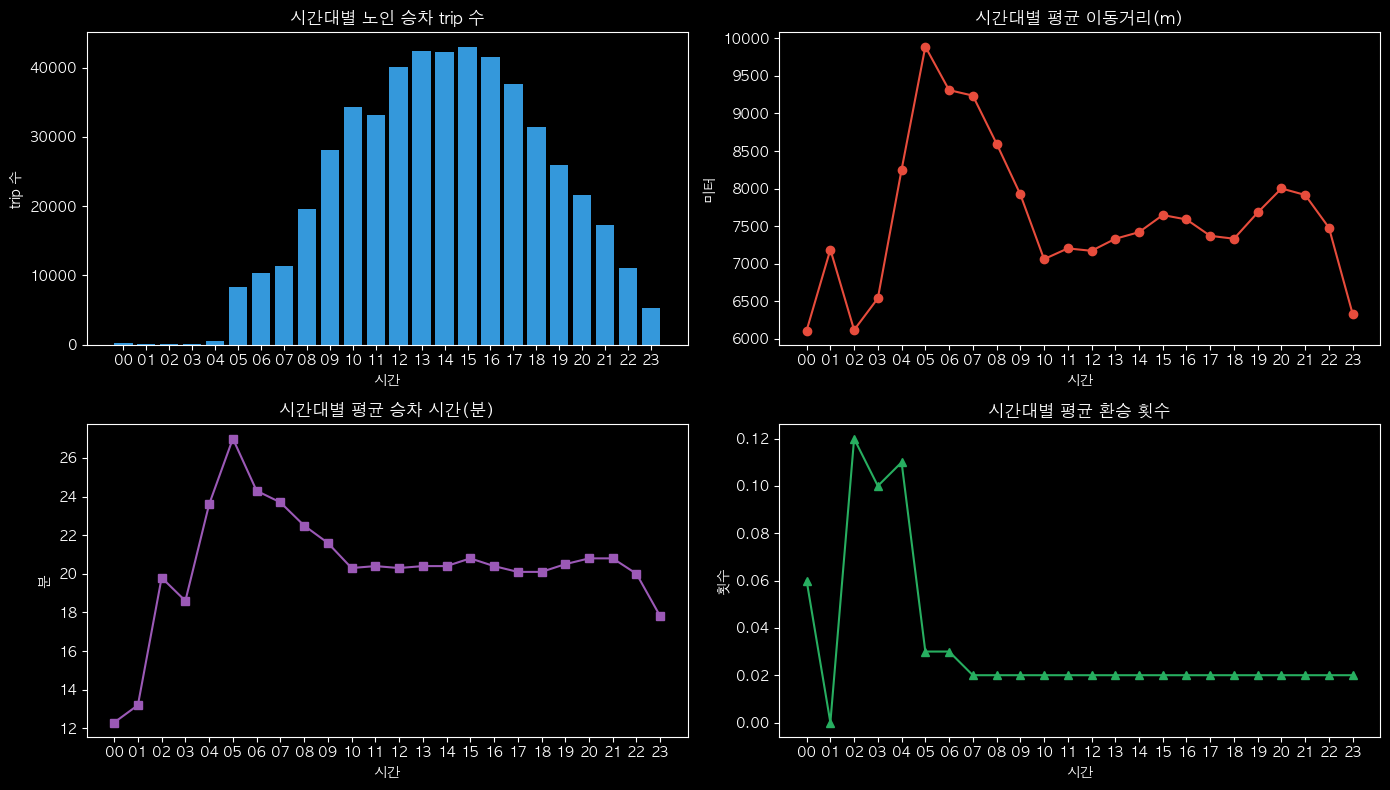


저장: elderly_time_pattern.png


In [41]:
# ============================================================
# 셀 6 - 시간대별 노인 승차/이동거리/환승 횟수
# ============================================================
with db_open(read_only=True) as con:
    by_hour = con.execute("""
        SELECT substr(ride_dt, 9, 2) AS hour,
               COUNT(*) AS trip_cnt,
               COUNT(DISTINCT vr_card_no) AS 고유노인,
               ROUND(AVG(utztn_dstnc), 0) AS 평균거리_m,
               ROUND(AVG(brdg_hr)/60.0, 1) AS 평균승차분,
               ROUND(AVG(trnf_cnt), 2) AS 평균환승횟수
        FROM elderly_card_trips
        WHERE ride_dt IS NOT NULL
        GROUP BY hour
        ORDER BY hour
    """).df()

print("=== 시간대별 노인 활동 ===")
print(by_hour.to_string())

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0,0].bar(by_hour['hour'], by_hour['trip_cnt'], color='#3498db')
axes[0,0].set_title('시간대별 노인 승차 trip 수')
axes[0,0].set_xlabel('시간'); axes[0,0].set_ylabel('trip 수')

axes[0,1].plot(by_hour['hour'], by_hour['평균거리_m'], marker='o', color='#e74c3c')
axes[0,1].set_title('시간대별 평균 이동거리(m)')
axes[0,1].set_xlabel('시간'); axes[0,1].set_ylabel('미터')

axes[1,0].plot(by_hour['hour'], by_hour['평균승차분'], marker='s', color='#9b59b6')
axes[1,0].set_title('시간대별 평균 승차 시간(분)')
axes[1,0].set_xlabel('시간'); axes[1,0].set_ylabel('분')

axes[1,1].plot(by_hour['hour'], by_hour['평균환승횟수'], marker='^', color='#27ae60')
axes[1,1].set_title('시간대별 평균 환승 횟수')
axes[1,1].set_xlabel('시간'); axes[1,1].set_ylabel('횟수')

plt.tight_layout()
plt.savefig('elderly_time_pattern.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n저장: elderly_time_pattern.png")

=== 시간대 × 환승유형별 평균 환승시간(초) ===
trnf_type_cd      BB      BT      TB     TT
hour                                       
00             850.0   519.0   904.0  203.0
01            1181.0  1154.0  1463.0   93.0
02            1304.0     NaN  3679.0   37.0
03            1084.0     NaN     NaN    NaN
04             684.0   922.0   918.0  162.0
05             645.0   393.0   449.0  219.0
06             540.0   269.0   491.0  347.0
07             449.0   284.0   464.0  333.0
08             489.0   317.0   503.0  378.0
09             571.0   361.0   567.0  368.0
10             642.0   406.0   639.0  365.0
11             661.0   432.0   683.0  350.0
12             649.0   438.0   688.0  343.0
13             650.0   450.0   697.0  335.0
14             670.0   472.0   727.0  330.0
15             675.0   481.0   742.0  331.0
16             671.0   473.0   749.0  324.0
17             650.0   448.0   745.0  320.0
18             619.0   427.0   738.0  311.0
19             589.0   409.0   732.0  304.0
2

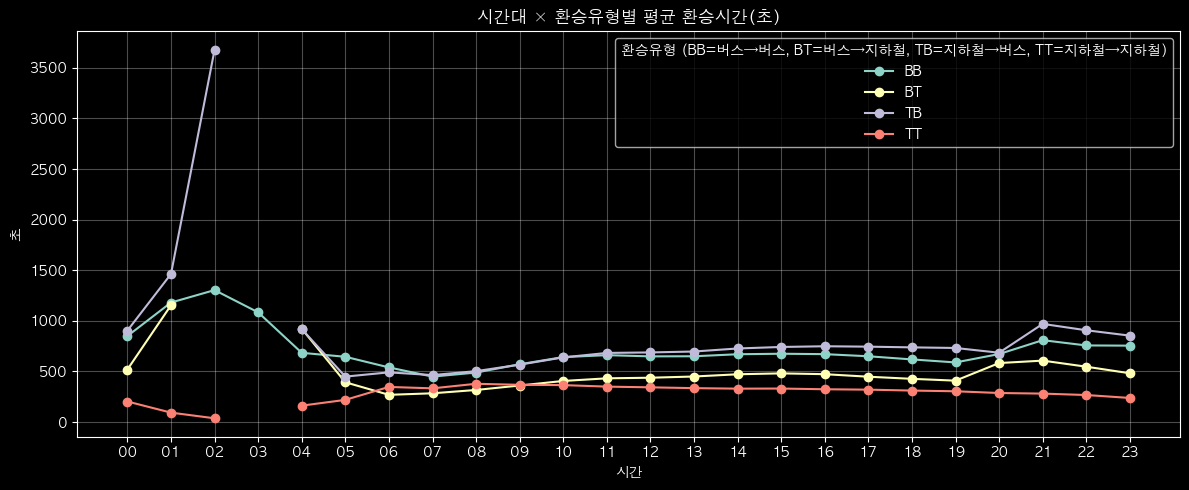


저장: transfer_time_by_hour.png


In [42]:
# ============================================================
# 셀 7 - 시간대별 환승 시간 (transfer_accessibility 결합)
# ============================================================
# 컬럼 의미:
#   trnf_hr    = SUM 환승시간(초) — 인원 전체 합산
#   pasg_cnt   = 환승 인원수
#   pasg_nope  = 환승 인원수 (대개 pasg_cnt와 같음)
# ⇒ 평균 환승시간(초) = SUM(trnf_hr) / SUM(pasg_cnt)
with db_open(read_only=True) as con:
    trans_hour = con.execute("""
        SELECT tzon AS hour,
               trnf_type_cd,
               SUM(pasg_cnt) AS 환승인원,
               ROUND(SUM(trnf_hr * 1.0) / NULLIF(SUM(pasg_cnt), 0), 0) AS 평균환승시간_초
        FROM monthly_transfer_accessibility
        WHERE pasg_cnt > 0
        GROUP BY tzon, trnf_type_cd
        ORDER BY tzon, trnf_type_cd
    """).df()

print("=== 시간대 × 환승유형별 평균 환승시간(초) ===")
pivot = trans_hour.pivot(index='hour', columns='trnf_type_cd', values='평균환승시간_초')
print(pivot.to_string())

# 시각화
fig, ax = plt.subplots(figsize=(12, 5))
for col in pivot.columns:
    ax.plot(pivot.index, pivot[col], marker='o', label=col)
ax.set_title('시간대 × 환승유형별 평균 환승시간(초)')
ax.set_xlabel('시간'); ax.set_ylabel('초')
ax.legend(title='환승유형 (BB=버스→버스, BT=버스→지하철, TB=지하철→버스, TT=지하철→지하철)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('transfer_time_by_hour.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n저장: transfer_time_by_hour.png")

In [43]:
# ============================================================
# 셀 8 - 카드 단위 분석: 하루 trip 횟수, 환승 횟수 분포
# ============================================================
with db_open(read_only=True) as con:
    per_card = con.execute("""
        SELECT vr_card_no,
               COUNT(*) AS 일일trip수,
               SUM(utztn_dstnc) AS 일일총거리_m,
               MAX(trnf_cnt) AS 최대환승,
               substr(MIN(ride_dt), 9, 2) AS 첫승차시간,
               substr(MAX(ride_dt), 9, 2) AS 막승차시간
        FROM elderly_card_trips
        GROUP BY vr_card_no
    """).df()

print(f"=== 카드 단위 통계 ({len(per_card):,}명) ===")
print(per_card[['일일trip수','일일총거리_m','최대환승']].describe().round(0).to_string())

print("\n=== 일일 trip 횟수 분포 ===")
print(per_card['일일trip수'].value_counts().sort_index().head(10).to_string())

print("\n=== 첫 승차 시간 분포 (외출 시작) ===")
print(per_card['첫승차시간'].value_counts().sort_index().to_string())

=== 카드 단위 통계 (342,976명) ===
        일일trip수   일일총거리_m      최대환승
count  342976.0  342976.0  342976.0
mean        1.0   11233.0       0.0
std         1.0   11662.0       0.0
min         1.0       0.0       0.0
25%         1.0    3200.0       0.0
50%         1.0    7700.0       0.0
75%         2.0   15400.0       0.0
max        26.0  290700.0       4.0

=== 일일 trip 횟수 분포 ===
일일trip수
1     234896
2      72621
3      23220
4       7910
5       2695
6       1022
7        379
8        134
9         57
10        21

=== 첫 승차 시간 분포 (외출 시작) ===
첫승차시간
00      171
01       19
02       17
03       40
04      535
05     8041
06     9896
07    10576
08    17856
09    24816
10    28737
11    26052
12    30745
13    30326
14    28016
15    27017
16    24317
17    20710
18    16283
19    12977
20    10565
21     8153
22     4803
23     2308


---

## 3. 노선·운영사별 노인 점유율

어느 노선/운영사가 노인을 많이 운반하는가?

In [44]:
# ============================================================
# 셀 9 - 운영주체(trfc_mns_cd)별 노인 trip 분포
# ============================================================
with db_open(read_only=True) as con:
    op_dist = con.execute("""
        SELECT ect.clcln_bzmn_trfc_mns_cd AS code,
               ANY_VALUE(t.clcln_bzmn_trfc_mns_nm) AS 운영주체,
               COUNT(*) AS trip_cnt,
               COUNT(DISTINCT ect.rte_id) AS 노선수,
               COUNT(DISTINCT ect.vr_card_no) AS 고유노인
        FROM elderly_card_trips ect
        LEFT JOIN trfc_mns t ON t.clcln_bzmn_trfc_mns_cd = ect.clcln_bzmn_trfc_mns_cd
                            AND t.clcln_bzmn_id = ect.clcln_bzmn_id
        WHERE ect.clcln_bzmn_trfc_mns_cd IS NOT NULL
        GROUP BY code
        ORDER BY trip_cnt DESC
        LIMIT 20
    """).df()

print("=== 운영주체별 노인 trip TOP 20 ===")
print(op_dist.to_string())

=== 운영주체별 노인 trip TOP 20 ===
   code                      운영주체  trip_cnt  노선수    고유노인
0   201               서울교통공사(1-4)    208645    5  152831
1   203               서울교통공사(5-8)    146569    4  110437
2   202                    한국철도공사     52025    8   42251
3   105                 마을버스(105)     19306  241   15218
4   205                       9호선     17943    1   14339
5   115                      간선버스     16517  129   13696
6   120                 지선버스(120)     16320  205   13473
7   235                   우이신설경전철      9870    1    7241
8   237                    남서울경전철      5826    1    4652
9   208                      신분당선      3197    1    2748
10  206                      공항철도      2156    1    1789
11  500       경기일반버스(500)-초승거리비례제      1381   96    1277
12  210                     새서울철도      1294    1    1122
13  533                 경기좌석(533)      1124  144    1016
14  290               수도권광역급행철도에이      1117    1     841
15  121                 지선버스(121)       865   13     686
16

In [45]:
# ============================================================
# 셀 10 - 노선별 노인 trip TOP — 가장 노인 많이 타는 노선
# ============================================================
with db_open(read_only=True) as con:
    rte_top = con.execute("""
        SELECT ect.rte_id,
               ANY_VALUE(rs.rte_no) AS 노선번호,
               ANY_VALUE(rs.rte_nm) AS 노선명,
               ANY_VALUE(rl.rte_nm) AS 지하철노선명,
               COUNT(*) AS 노인trip,
               COUNT(DISTINCT ect.vr_card_no) AS 고유노인,
               ROUND(AVG(ect.utztn_dstnc), 0) AS 평균거리_m,
               ROUND(AVG(ect.brdg_hr)/60.0, 1) AS 평균승차분,
               ANY_VALUE(ect.clcln_bzmn_trfc_mns_cd) AS 운영주체코드
        FROM elderly_card_trips ect
        LEFT JOIN route_station rs ON rs.rte_id = ect.rte_id
        LEFT JOIN railway_line rl ON rl.rte_id = ect.rte_id AND rl.sarea_nm='수도권'
        GROUP BY ect.rte_id
        ORDER BY 노인trip DESC
        LIMIT 30
    """).df()

print("=== 노인 trip TOP 30 노선 ===")
# 지하철 노선이 있으면 노선명 대체
rte_top['표시명'] = rte_top['노선명'].fillna(rte_top['지하철노선명'])
print(rte_top[['rte_id','노선번호','표시명','노인trip','고유노인','평균거리_m','평균승차분','운영주체코드']].to_string())

=== 노인 trip TOP 30 노선 ===
      rte_id  노선번호                   표시명  노인trip   고유노인   평균거리_m  평균승차분 운영주체코드
0        002   NaN                   2호선   76763  57534   8502.0   22.3    201
1   11110018   147          147번(월계동도곡동)   59685    462   2597.0   11.5    115
2   11110014   143           143번(정릉개포동)   56658    443   2649.0   10.6    115
3        205   NaN                   5호선   56334  42832   7348.0   21.2    203
4        207   NaN                   7호선   46502  36255   7291.0   20.8    203
5        003   NaN                   3호선   46210  36071   8286.0   22.0    201
6        004   NaN                   4호선   46158  35016   8005.0   21.3    201
7   11110336   421          421번(염곡동옥수동)   42636    319   2087.0   10.0    115
8   11110953   202          202번(불암동후암동)   40479    281   3707.0   14.3    115
9   11110354  7212  7212번(은평차고지극동그린아파트앞)   40183    254   2083.0    9.5    120
10  11110013   142        142번(도봉동고속터미널)   36994    322   2853.0   11.1    115
11  11110032   262      26

=== 교통수단 분류별 노인 이용 ===
         분류  trip_cnt    고유노인   평균거리_m  평균승차분
0      도시철도    430535  299722   8251.0   22.2
1    버스(시내)     53365   39851   2373.0   10.5
2  도시철도/경전철     18181   13915   6444.0   17.4
3   광역/마을버스      3640    3279  15332.0   24.7
4        기타        33      30  27077.0   31.0


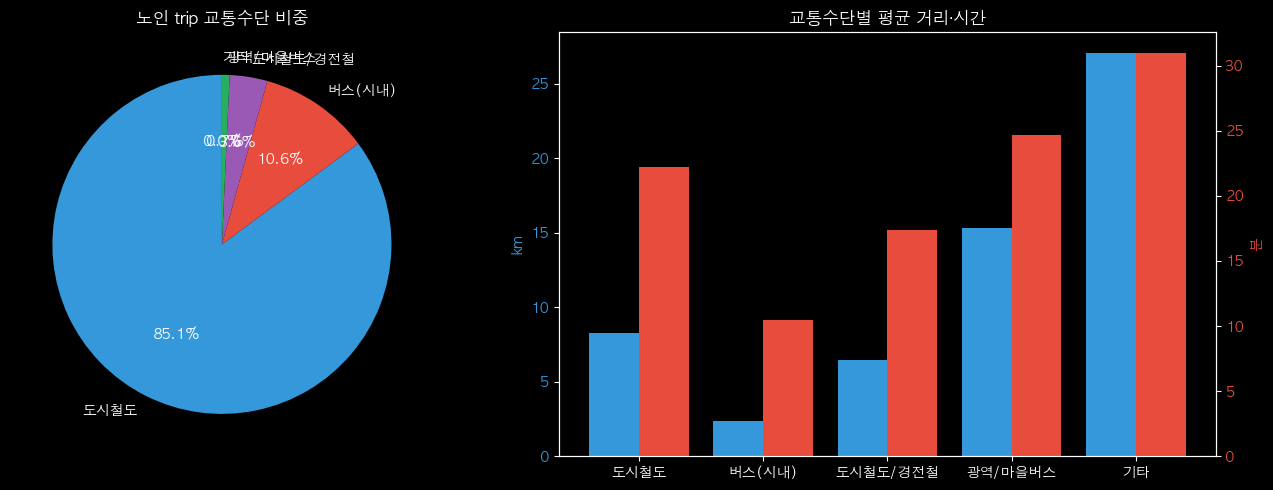


저장: elderly_by_mode.png


In [46]:
# ============================================================
# 셀 11 - 분류별 비중 (버스 vs 지하철, 시각화)
# ============================================================
with db_open(read_only=True) as con:
    by_kind = con.execute("""
        SELECT 
            CASE 
                WHEN clcln_bzmn_trfc_mns_cd LIKE '20%' THEN '도시철도'
                WHEN clcln_bzmn_trfc_mns_cd IN ('235','237','290','208','210','236') THEN '도시철도/경전철'
                WHEN clcln_bzmn_trfc_mns_cd LIKE '1%' THEN '버스(시내)'
                WHEN clcln_bzmn_trfc_mns_cd LIKE '5%' THEN '광역/마을버스'
                ELSE '기타'
            END AS 분류,
            COUNT(*) AS trip_cnt,
            COUNT(DISTINCT vr_card_no) AS 고유노인,
            ROUND(AVG(utztn_dstnc), 0) AS 평균거리_m,
            ROUND(AVG(brdg_hr)/60.0, 1) AS 평균승차분
        FROM elderly_card_trips
        GROUP BY 분류
        ORDER BY trip_cnt DESC
    """).df()

print("=== 교통수단 분류별 노인 이용 ===")
print(by_kind.to_string())

# Pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].pie(by_kind['trip_cnt'], labels=by_kind['분류'], autopct='%1.1f%%', startangle=90,
           colors=['#3498db','#e74c3c','#9b59b6','#27ae60','#95a5a6'])
axes[0].set_title('노인 trip 교통수단 비중')

# 평균 거리·승차시간 비교
x = range(len(by_kind))
ax2 = axes[1]
ax2.bar([i-0.2 for i in x], by_kind['평균거리_m']/1000, width=0.4, label='평균거리(km)', color='#3498db')
ax2.set_ylabel('km', color='#3498db')
ax2.tick_params(axis='y', labelcolor='#3498db')
ax3 = ax2.twinx()
ax3.bar([i+0.2 for i in x], by_kind['평균승차분'], width=0.4, label='평균승차분', color='#e74c3c')
ax3.set_ylabel('분', color='#e74c3c')
ax3.tick_params(axis='y', labelcolor='#e74c3c')
ax2.set_xticks(list(x))
ax2.set_xticklabels(by_kind['분류'])
ax2.set_title('교통수단별 평균 거리·시간')
plt.tight_layout()
plt.savefig('elderly_by_mode.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n저장: elderly_by_mode.png")

---

## 4. Chart.js 인터랙티브 대시보드

위 모든 분석을 하나의 HTML 페이지로 — 탭, 호버, 줌 가능

In [47]:
# ============================================================
# 셀 12 - Chart.js 대시보드 HTML 생성
# ============================================================
# 이전 셀들의 변수를 그대로 사용 (셀 1~11 먼저 실행되어야 함)
# 산출물: seoul_elderly_dashboard.html

# 데이터 → JSON 직렬화
data = {
    # 1. OD
    "od_top": od.head(20)[['ride_nm','goff_nm','goff_ctpv','trip_cnt']].to_dict('records'),
    "summary": summary.reset_index().to_dict('records'),

    # 2. 시간대
    "by_hour": by_hour.to_dict('records'),
    "transfer_pivot": {
        "hours": list(pivot.index),
        "BB": [None if pd.isna(v) else float(v) for v in pivot.get('BB', pd.Series([None]*len(pivot)))],
        "BT": [None if pd.isna(v) else float(v) for v in pivot.get('BT', pd.Series([None]*len(pivot)))],
        "TB": [None if pd.isna(v) else float(v) for v in pivot.get('TB', pd.Series([None]*len(pivot)))],
        "TT": [None if pd.isna(v) else float(v) for v in pivot.get('TT', pd.Series([None]*len(pivot)))],
    },
    "first_ride_dist": per_card['첫승차시간'].value_counts().sort_index().to_dict(),
    "trip_cnt_dist": per_card['일일trip수'].value_counts().sort_index().head(10).to_dict(),

    # 3. 노선
    "by_kind": by_kind.to_dict('records'),
    "op_dist": op_dist.head(15).to_dict('records'),
    "rte_top": rte_top.head(20).assign(표시명=rte_top['노선명'].fillna(rte_top['지하철노선명'])).to_dict('records'),
}

import json as _json
data_json = _json.dumps(data, ensure_ascii=False, default=str)

html = f"""<!DOCTYPE html>
<html lang="ko">
<head>
<meta charset="UTF-8">
<title>서울 노인 trip 분석 대시보드</title>
<script src="https://cdn.jsdelivr.net/npm/chart.js@4.4.0/dist/chart.umd.min.js"></script>
<style>
* {{ margin: 0; padding: 0; box-sizing: border-box; }}
body {{
  font-family: -apple-system, 'Apple SD Gothic Neo', 'Pretendard', system-ui, sans-serif;
  background: #f5f7fa;
  color: #2c3e50;
  line-height: 1.5;
}}
header {{
  background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
  color: white; padding: 24px 32px;
  box-shadow: 0 2px 10px rgba(0,0,0,.1);
}}
header h1 {{ font-size: 22px; font-weight: 700; }}
header .sub {{ font-size: 13px; opacity: .85; margin-top: 4px; }}
.tabs {{
  display: flex; gap: 4px; padding: 0 32px; background: white;
  border-bottom: 1px solid #e1e4e8; position: sticky; top: 0; z-index: 100;
}}
.tab {{
  padding: 14px 20px; cursor: pointer; font-weight: 500;
  border-bottom: 3px solid transparent; color: #5a6c7d; user-select: none;
  transition: all .15s;
}}
.tab:hover {{ color: #2c3e50; background: #f8fafc; }}
.tab.active {{ color: #667eea; border-bottom-color: #667eea; }}
.section {{ display: none; padding: 24px 32px; max-width: 1400px; margin: 0 auto; }}
.section.active {{ display: block; }}
.grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(450px, 1fr)); gap: 20px; }}
.card {{
  background: white; border-radius: 12px; padding: 20px;
  box-shadow: 0 1px 3px rgba(0,0,0,.06); border: 1px solid #e1e4e8;
}}
.card h3 {{ font-size: 15px; margin-bottom: 12px; color: #2c3e50; font-weight: 600; }}
.card .desc {{ font-size: 12px; color: #7a8693; margin-bottom: 14px; }}
.chart-wrap {{ position: relative; height: 320px; }}
.chart-wrap.tall {{ height: 420px; }}
table {{ width: 100%; border-collapse: collapse; font-size: 13px; }}
th, td {{ padding: 8px 10px; text-align: left; border-bottom: 1px solid #eef1f4; }}
th {{ background: #f8fafc; font-weight: 600; color: #5a6c7d; font-size: 11px; text-transform: uppercase; }}
td.num {{ text-align: right; font-variant-numeric: tabular-nums; }}
.badge {{
  display: inline-block; padding: 2px 8px; font-size: 11px;
  background: #ecf0fb; color: #667eea; border-radius: 4px; font-weight: 500;
}}
.kpi-row {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(200px, 1fr)); gap: 12px; margin-bottom: 20px; }}
.kpi {{
  background: white; padding: 16px 20px; border-radius: 10px;
  border: 1px solid #e1e4e8; box-shadow: 0 1px 2px rgba(0,0,0,.04);
}}
.kpi .label {{ font-size: 12px; color: #7a8693; }}
.kpi .value {{ font-size: 24px; font-weight: 700; color: #2c3e50; margin-top: 4px; }}
.kpi .delta {{ font-size: 11px; color: #5a6c7d; margin-top: 2px; }}
</style>
</head>
<body>
<header>
<h1>🚸 서울 노인 trip 분석 대시보드</h1>
<div class="sub">elderly_card_trips · 2026-02-22(일) · 노인 342,976명 / 505,754 trips</div>
</header>

<div class="tabs">
<div class="tab active" data-tab="od">📍 OD 흐름</div>
<div class="tab" data-tab="time">🕐 시간대 활동</div>
<div class="tab" data-tab="route">🚌 노선·운영사</div>
</div>

<!-- OD -->
<div class="section active" id="sec-od">
<div class="kpi-row">
<div class="kpi"><div class="label">총 OD 페어 (서울 출발)</div><div class="value" id="kpi-od-total"></div></div>
<div class="kpi"><div class="label">총 trip</div><div class="value" id="kpi-od-trip"></div></div>
<div class="kpi"><div class="label">자족 비율 평균</div><div class="value" id="kpi-od-self"></div></div>
</div>
<div class="grid">
<div class="card">
<h3>TOP 20 OD 페어 (출발구 → 도착구)</h3>
<div class="desc">노인이 가장 많이 다니는 구→구 흐름</div>
<div class="chart-wrap tall"><canvas id="chart-od-top"></canvas></div>
</div>
<div class="card">
<h3>구별 자족 vs 출타 (자기 구 내 이동 비율)</h3>
<div class="desc">자족비율 = 같은 구 내 이동 / 전체 trip</div>
<div class="chart-wrap tall"><canvas id="chart-self"></canvas></div>
</div>
<div class="card" style="grid-column: 1 / -1;">
<h3>구별 노인 trip 발생량 + 비율</h3>
<table id="tbl-summary">
<thead><tr><th>구</th><th class="num">전체 trip</th><th class="num">자기 구내</th><th class="num">서울 외</th><th class="num">자족 %</th><th class="num">서울외 %</th></tr></thead>
<tbody></tbody></table>
</div>
</div>
</div>

<!-- 시간대 -->
<div class="section" id="sec-time">
<div class="grid">
<div class="card">
<h3>시간대별 노인 승차 trip 수</h3>
<div class="desc">언제 가장 많이 외출/이동하는가</div>
<div class="chart-wrap"><canvas id="chart-hour-trip"></canvas></div>
</div>
<div class="card">
<h3>시간대별 평균 이동거리</h3>
<div class="chart-wrap"><canvas id="chart-hour-dist"></canvas></div>
</div>
<div class="card">
<h3>시간대별 평균 승차 시간</h3>
<div class="chart-wrap"><canvas id="chart-hour-bridge"></canvas></div>
</div>
<div class="card">
<h3>시간대별 평균 환승 횟수</h3>
<div class="chart-wrap"><canvas id="chart-hour-trnf"></canvas></div>
</div>
<div class="card" style="grid-column: 1 / -1;">
<h3>시간대 × 환승 유형별 평균 환승 시간(초)</h3>
<div class="desc">BB=버스→버스 / BT=버스→지하철 / TB=지하철→버스 / TT=지하철→지하철</div>
<div class="chart-wrap tall"><canvas id="chart-transfer-pivot"></canvas></div>
</div>
<div class="card">
<h3>첫 승차 시간 분포 (외출 시작)</h3>
<div class="chart-wrap"><canvas id="chart-first-ride"></canvas></div>
</div>
<div class="card">
<h3>일일 trip 횟수 분포</h3>
<div class="chart-wrap"><canvas id="chart-trip-cnt"></canvas></div>
</div>
</div>
</div>

<!-- 노선 -->
<div class="section" id="sec-route">
<div class="grid">
<div class="card">
<h3>교통수단 분류별 노인 이용 비중</h3>
<div class="chart-wrap"><canvas id="chart-by-kind"></canvas></div>
</div>
<div class="card">
<h3>운영주체별 노인 trip TOP 15</h3>
<div class="chart-wrap tall"><canvas id="chart-op-dist"></canvas></div>
</div>
<div class="card" style="grid-column: 1 / -1;">
<h3>노선별 노인 trip TOP 20</h3>
<div class="chart-wrap tall"><canvas id="chart-rte-top"></canvas></div>
</div>
<div class="card" style="grid-column: 1 / -1;">
<h3>TOP 30 노선 표</h3>
<table id="tbl-rte">
<thead><tr><th>노선번호</th><th>노선명</th><th class="num">노인 trip</th><th class="num">고유 노인</th><th class="num">평균거리(m)</th><th class="num">평균승차분</th><th>운영주체</th></tr></thead>
<tbody></tbody></table>
</div>
</div>
</div>

<script>
const DATA = {data_json};

// 탭 전환
document.querySelectorAll('.tab').forEach(t => {{
  t.addEventListener('click', () => {{
    document.querySelectorAll('.tab').forEach(x => x.classList.remove('active'));
    document.querySelectorAll('.section').forEach(x => x.classList.remove('active'));
    t.classList.add('active');
    document.getElementById('sec-' + t.dataset.tab).classList.add('active');
  }});
}});

// 색상 팔레트
const PALETTE = ['#667eea','#764ba2','#f093fb','#f5576c','#4facfe','#43e97b','#38f9d7','#fa709a','#fee140','#feca57'];

// === OD 섹션 ===
const odTopLabels = DATA.od_top.map(d => `${{d.ride_nm}}→${{d.goff_nm}}`);
const odTopValues = DATA.od_top.map(d => d.trip_cnt);
new Chart(document.getElementById('chart-od-top'), {{
  type: 'bar',
  data: {{ labels: odTopLabels, datasets: [{{ label: 'Trip 수', data: odTopValues, backgroundColor: '#667eea' }}] }},
  options: {{ indexAxis: 'y', responsive: true, maintainAspectRatio: false,
    plugins: {{ legend: {{ display: false }} }},
    scales: {{ y: {{ ticks: {{ font: {{ size: 11 }} }} }} }} }}
}});

const summarySorted = [...DATA.summary].sort((a,b) => b.전체trip - a.전체trip);
new Chart(document.getElementById('chart-self'), {{
  type: 'bar',
  data: {{
    labels: summarySorted.map(d => d.ride_nm),
    datasets: [
      {{ label: '자족 %', data: summarySorted.map(d => d.자족비율), backgroundColor: '#43e97b' }},
      {{ label: '서울외 %', data: summarySorted.map(d => d.서울외비율), backgroundColor: '#f5576c' }}
    ]
  }},
  options: {{ indexAxis: 'y', responsive: true, maintainAspectRatio: false }}
}});

const tblSummary = document.querySelector('#tbl-summary tbody');
summarySorted.forEach(d => {{
  tblSummary.insertAdjacentHTML('beforeend',
    `<tr><td>${{d.ride_nm}}</td>` +
    `<td class="num">${{d.전체trip.toLocaleString()}}</td>` +
    `<td class="num">${{d.자기구내.toLocaleString()}}</td>` +
    `<td class="num">${{d.서울외.toLocaleString()}}</td>` +
    `<td class="num"><span class="badge">${{d.자족비율}}%</span></td>` +
    `<td class="num">${{d.서울외비율}}%</td></tr>`);
}});

document.getElementById('kpi-od-total').textContent = DATA.summary.length + ' (구) / 페어 ' + DATA.od_top.length + '+';
document.getElementById('kpi-od-trip').textContent = summarySorted.reduce((s,d) => s + d.전체trip, 0).toLocaleString();
const avgSelf = (summarySorted.reduce((s,d) => s + d.자족비율, 0) / summarySorted.length).toFixed(1);
document.getElementById('kpi-od-self').textContent = avgSelf + '%';

// === 시간대 섹션 ===
const hours = DATA.by_hour.map(d => d.hour + '시');
function hourChart(canvasId, key, color, label) {{
  new Chart(document.getElementById(canvasId), {{
    type: 'line',
    data: {{ labels: hours, datasets: [{{ label: label, data: DATA.by_hour.map(d => d[key]),
      borderColor: color, backgroundColor: color + '33', fill: true, tension: .35 }}] }},
    options: {{ responsive: true, maintainAspectRatio: false,
      plugins: {{ legend: {{ display: false }} }} }}
  }});
}}
hourChart('chart-hour-trip', 'trip_cnt', '#667eea', 'Trip 수');
hourChart('chart-hour-dist', '평균거리_m', '#f5576c', '평균 거리(m)');
hourChart('chart-hour-bridge', '평균승차분', '#43e97b', '평균 승차(분)');
hourChart('chart-hour-trnf', '평균환승횟수', '#feca57', '평균 환승 횟수');

// 환승 pivot
const pv = DATA.transfer_pivot;
new Chart(document.getElementById('chart-transfer-pivot'), {{
  type: 'line',
  data: {{ labels: pv.hours.map(h => h + '시'), datasets: [
    {{ label: 'BB (버스→버스)',  data: pv.BB, borderColor: '#667eea', backgroundColor: 'transparent', tension: .3 }},
    {{ label: 'BT (버스→지하철)', data: pv.BT, borderColor: '#f5576c', backgroundColor: 'transparent', tension: .3 }},
    {{ label: 'TB (지하철→버스)', data: pv.TB, borderColor: '#43e97b', backgroundColor: 'transparent', tension: .3 }},
    {{ label: 'TT (지하철→지하철)',data: pv.TT, borderColor: '#feca57', backgroundColor: 'transparent', tension: .3 }}
  ] }},
  options: {{ responsive: true, maintainAspectRatio: false,
    scales: {{ y: {{ title: {{ display: true, text: '환승시간(초)' }} }} }} }}
}});

// 첫 승차 / 일일 trip
const fr = DATA.first_ride_dist;
new Chart(document.getElementById('chart-first-ride'), {{
  type: 'bar',
  data: {{ labels: Object.keys(fr).map(h => h+'시'),
    datasets: [{{ label: '인원', data: Object.values(fr), backgroundColor: '#764ba2' }}] }},
  options: {{ responsive: true, maintainAspectRatio: false, plugins: {{ legend: {{ display: false }} }} }}
}});

const tc = DATA.trip_cnt_dist;
new Chart(document.getElementById('chart-trip-cnt'), {{
  type: 'bar',
  data: {{ labels: Object.keys(tc).map(n => n+'회'),
    datasets: [{{ label: '카드 수', data: Object.values(tc), backgroundColor: '#4facfe' }}] }},
  options: {{ responsive: true, maintainAspectRatio: false, plugins: {{ legend: {{ display: false }} }} }}
}});

// === 노선 섹션 ===
new Chart(document.getElementById('chart-by-kind'), {{
  type: 'doughnut',
  data: {{ labels: DATA.by_kind.map(d => d.분류),
    datasets: [{{ data: DATA.by_kind.map(d => d.trip_cnt),
      backgroundColor: PALETTE.slice(0, DATA.by_kind.length) }}] }},
  options: {{ responsive: true, maintainAspectRatio: false,
    plugins: {{ legend: {{ position: 'bottom' }} }} }}
}});

new Chart(document.getElementById('chart-op-dist'), {{
  type: 'bar',
  data: {{ labels: DATA.op_dist.map(d => d.운영주체 || ('코드 ' + d.code)),
    datasets: [{{ label: 'Trip 수', data: DATA.op_dist.map(d => d.trip_cnt), backgroundColor: '#764ba2' }}] }},
  options: {{ indexAxis: 'y', responsive: true, maintainAspectRatio: false,
    plugins: {{ legend: {{ display: false }} }} }}
}});

new Chart(document.getElementById('chart-rte-top'), {{
  type: 'bar',
  data: {{ labels: DATA.rte_top.map(d => (d.노선번호 || d.표시명 || d.rte_id) + ' / ' + (d.표시명 || '')),
    datasets: [{{ label: 'Trip 수', data: DATA.rte_top.map(d => d.노인trip), backgroundColor: '#43e97b' }}] }},
  options: {{ indexAxis: 'y', responsive: true, maintainAspectRatio: false,
    plugins: {{ legend: {{ display: false }} }},
    scales: {{ y: {{ ticks: {{ font: {{ size: 10 }} }} }} }} }}
}});

const tblRte = document.querySelector('#tbl-rte tbody');
DATA.rte_top.forEach(d => {{
  tblRte.insertAdjacentHTML('beforeend',
    `<tr><td>${{d.노선번호 || '-'}}</td>` +
    `<td>${{d.표시명 || d.rte_id}}</td>` +
    `<td class="num">${{d.노인trip.toLocaleString()}}</td>` +
    `<td class="num">${{d.고유노인.toLocaleString()}}</td>` +
    `<td class="num">${{Number(d.평균거리_m).toLocaleString()}}</td>` +
    `<td class="num">${{d.평균승차분}}</td>` +
    `<td><span class="badge">${{d.운영주체코드}}</span></td></tr>`);
}});
</script>
</body>
</html>
"""

Path('seoul_elderly_dashboard.html').write_text(html, encoding='utf-8')
print(f"✅ 생성: seoul_elderly_dashboard.html")
print(f"\n로컬 서버 띄워서 보세요:")
print(f"  python3 -m http.server 8000")
print(f"  → http://localhost:8000/seoul_elderly_dashboard.html")

✅ 생성: seoul_elderly_dashboard.html

로컬 서버 띄워서 보세요:
  python3 -m http.server 8000
  → http://localhost:8000/seoul_elderly_dashboard.html
